# Klaszterezés

- Definíció: Az adatok között rejtett kategóriákat keresünk
- Az egyes adatokhoz egy rejtett címkét ($z_n$) rendelünk
- Példa:
    - Dokumentumok csoportosítása témák szerint (politika, sport, gazdaság)
    - Képek automatikus csoportosítása anélkül, hogy előre tudnánk, milyen tárgyakat ábrázolnak
- Fontos: A klaszterezés nem azonos az osztályozással: az osztályozásnál címkézett adataink vannak, a klaszterezés a gyakorlatban csoportosítás

---
## k-Means

- Az adatok közelsége alapján csoportosítjuk az elemeket
- Minden klaszterhez egy prototípus pontot (cluster center) rendelünk: $μ_k$

A K-Means klaszterezés lépései:
- Inicializálás: véletlenszerű középpontok
- Hozzárendelés: adatpontokat besoroljuk a legközelebbi klaszterbe
- Frissítés: új klaszterközéppontokat számítunk
- Több ismétlés után a végső klaszterek (nincs változás vagy max iteráció szám)

__Paraméterek:__
- __n_clusters__: klaszterek száma, K (kötelező megadni)
- n_init: hány különböző inicializálással fusson le az algoritmus
(alapértelmezetten: 10)
- max_iter: maximális iterációszám egy futás során (alapértelmezetten 300)
- tol: konvergenciaküszöb – ha a középpontok változása kisebb ennél, az algoritmus megáll

__Output:__
- __cluster_centers___: a klaszterek középpontjainak koordinátái 
- __inertia___: pontok távolságainak (négyzeteinek) összege a saját cluster középpontjuktól (metrika: mennyire koncentráltak)
- n_iter_: ténylegesen lefutott iterációk száma a konvergenciáig

Text(0.5, 1.0, 'Adatok')

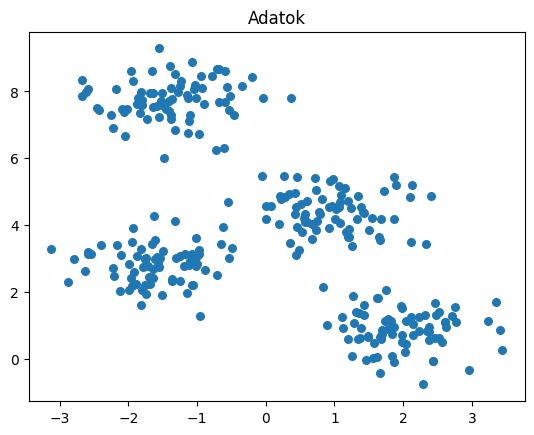

In [ ]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0) # 4 "pamacsot" hoz létre, random state: 0, hogy mindig ugyanazt az adatot generálja (zh-n is allitsuk be hogy a tanar is ugyanazt kapja)

import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], s=30) # osszes pont x koordinataja, y koordinataja, s: pontok merete
plt.title("Adatok")

Text(0.5, 1.0, 'K-means klaszterezés')

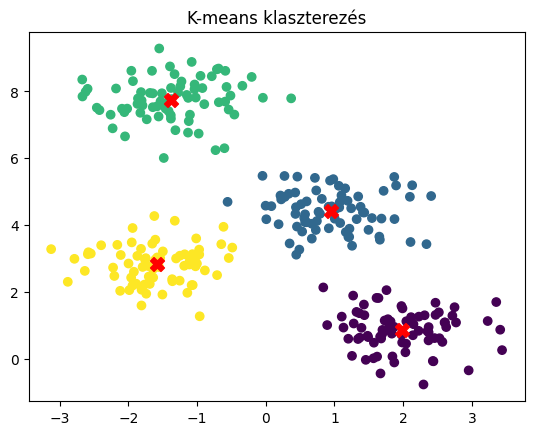

In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4, random_state=42) # k=4
model.fit(X) # nincs y!
labels = model.predict(X) # egy lépésben: labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=100, c='r', marker='X')
plt.title("K-means klaszterezés")

In [8]:
print("Középpontok:\n", model.cluster_centers_)
print("Inertia:", model.inertia_) # pontok távolságainak (négyzeteinek) összege a saját cluster középpontjuktól
print("Iterációk száma:", model.n_iter_) # amikor már nem változtak a cluster középpontok

Középpontok:
 [[ 1.98258281  0.86771314]
 [ 0.94973532  4.41906906]
 [-1.37324398  7.75368871]
 [-1.58438467  2.83081263]]
Inertia: 212.0059962108348
Iterációk száma: 3


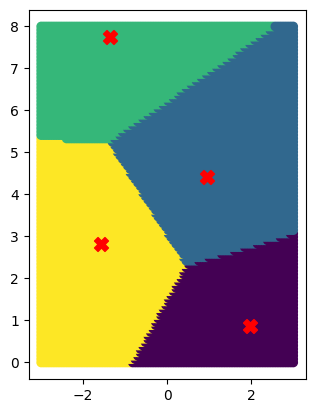

In [12]:
import numpy as np

xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(0, 8, 100)) 
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.gca().set_aspect('equal')
plt.scatter(xx, yy, c=Z) # Voronoi
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=100, c='r', marker='X')

A probléma:
- Túl kicsi K → Kevés klaszter, a csoportosítás nem elég pontos
- Túl nagy K → Minden adatpont dedikált klasztert kaphat, ami értelmetlen
- Érzékeny a kiindulási pontokra
- A K-Means durva hozzárendelést végez – minden pont egy klaszterhez tartozik
- K-Means __gömb alakú klasztereket feltételez__

K meghatározása:
- K értékének finomhangolása, amíg egy előre definiált heurisztika nem teljesül (pl. szórás összegek (inercia) vs. k diagrammon "__könyök pont__")
- __Hierarchikus klaszterezés__ (dendrogram): fa szerkezetű ábrázolás (először minden minta egy klaszter, majd a legközelebbi klaszterek egybevonása, minden lépésben eggyel kevesebb klaszter lesz, bottom-up)

Text(0, 0.5, 'variance (inertia)')

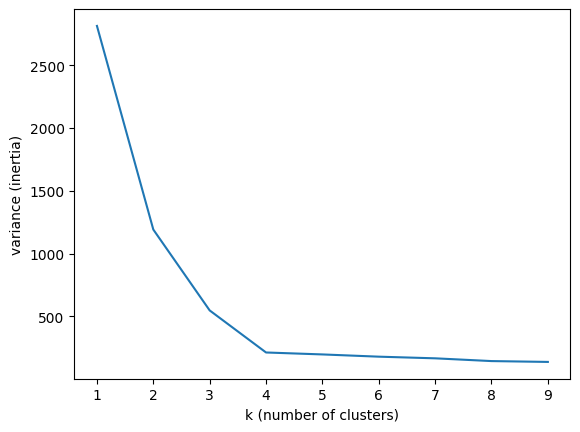

In [ ]:
x = [] # k értékek
i = [] # szórás értékek (aggregáltan)
for k in range(1, 10): # range(1, X.shape[0] + 1)
    model = KMeans(n_clusters=k)
    model.fit(X)
    x.append(k)
    i.append(model.inertia_)
    # print("k:", k, "inertia:", kmeans.inertia_)
plt.plot(x, i)
plt.xlabel("k (number of clusters)")
plt.ylabel("variance (inertia)")

## GMM (Gaussian Mixture Model)

- A GMM __valószínűségi klaszterezést__ alkalmaz – minden ponthoz hozzárendeli, hogy milyen valószínűséggel tartozik egy klaszterhez 
- Az EM (Expectation-Maximization) algoritmust használja a paraméterek finomhangolására (log-likelihood, kovariancia mátrix, parciális deriválás, de a hozzárendelésen kívül a lépések megegyeznek a k-Means lépéseivel)
- GMM képes __elliptikus klasztereket__ is modellezni
- Azt feltételezi, hogy az adatok több Gaussi eloszlásból származnak Az egyes klaszterek egy-egy Gauss-eloszlásként modellezhetők

__Parametérek:__

- __n_components__: komponensek (Gauss-eloszlások) száma (alapértelmezetten 1)
- max_iter: az EM algoritmus maximális iterációszáma (alapértelmezetten 100)
- tol: konvergenciaküszöb – ha a log-valószínűség változása kisebb ennél, megáll (alapértelmezetten 0.001)

__Output:__
- __means___: a komponensek középpontjai
- weights_: komponensekhez tartozó súlyok (nem teljesen a kaszterbe tartozó pontok számainak arányai (hard predict), hanem az egyes pontok valószínűségeinek átlaga az összes pontra, pl. 0. cluster: gmm.predict_proba(X)\[:,0\].sum()/X.shape\[0\])

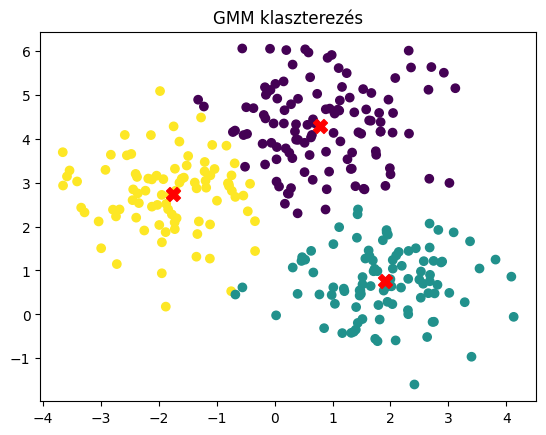

In [ ]:
# gmm már pl elipszioidokra is jo, mig a k-means csak körökre - a matek bonyi mogotte

X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.90, random_state=0)


from sklearn.mixture import GaussianMixture

model = GaussianMixture(n_components=3, random_state=42)
labels = model.fit_predict(X) # =  gmm.fit(X); labels = gmm.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("GMM klaszterezés")
plt.scatter(model.means_[:, 0], model.means_[:, 1], s=100, c='r', marker='X')

In [ ]:
print(model.means_) # cluster centers
print(model.weights_)

# weights...
# x_prob = model.predict_proba(X) #  x_prob[:,0]: mekkora a valószínűsége, hogy a pont a 0. klaszterbe tartozik
# x_prob[:,0].sum() / X.shape[0] # = weights_[0]

[[ 0.78948008  4.28667904]
 [ 1.90921727  0.75357197]
 [-1.76358365  2.74992532]]
[0.37793315 0.32612423 0.29594262]


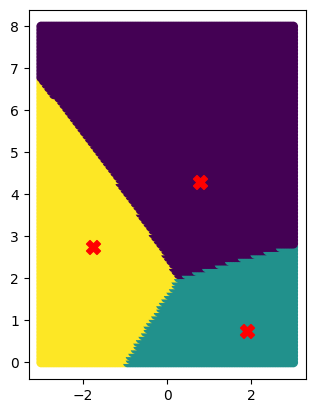

In [ ]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(0, 8, 100)) 
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.gca().set_aspect('equal')
plt.scatter(xx, yy, c=Z)
plt.scatter(model.means_[:, 0], model.means_[:, 1], s=100, c='r', marker='X')

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

- K-Means és GMM előfeltételezéseket tesznek a klaszterek alakjáról
- DBSCAN __nem igényli a klaszterek számának előzetes megadását__
- Kezeli a __különböző formájú__ klasztereket és __zaj__ adatokat
- probálja a sűrű pontokat egy clusterbe vonni, folyamatosan bővítve (alakja nem fontos)

Főbb fogalmak:
- __Magpont__ (core sample/point): ha legalább min_samples szomszédja van egy
ε sugarú környezetben
- __Határpont__ (border sample): egy magpont szomszédja (ε-on belül van), de maga
nem magpont, mert nincs sok (min_samples) szomszédja
- __Zaj__ (outlier): nem tartozik egyetlen klaszterhez sem (kevés szomszédja van, és azok sem core pontok)

Algoritmus (nagy vonalakban):
- meghatározzuk a pontok szomszédainak számát (adott ε esetén) => adott min_samples esetén, minden vagy pont magpont (>=) vagy határpont (<)
- egy random magpontból kiindulva minden szomszédot bevonunk a klaszterba, ha ez magpont volt onnan folytatjuk (rekurzívan)
- a maradék (az első klaszterből kimaradó) pontok közül választunk egy új magpontot, és megcsináljuk a második klasztert
- stb.
- a végén maradhatnak klaszteren kívüli határpontok, ez az utolsó klaszter

__Paraméterek:__
- __eps__ (ε): a maximális távolság, amelyen belül két pont szomszédnak számít
- __min_samples__: minimális számú szomszéd, amely szükséges egy pont magpontként való azonosításához
  
__Output:__
- __labels___: minden minta klasztercímkéje; a __-1 érték zajpontot jelez__
- components_: a magpontok tényleges koordinátái
- core_sample_indices_: azoknak a mintáknak az indexei, amelyek magpontok


FIGYELEM: nincsenek klaszter középpontok és nincsen predict metódus, új adat esetén új tanítás kell: __fit_predict__ !




Összes adat: 300
Magpontok: 300


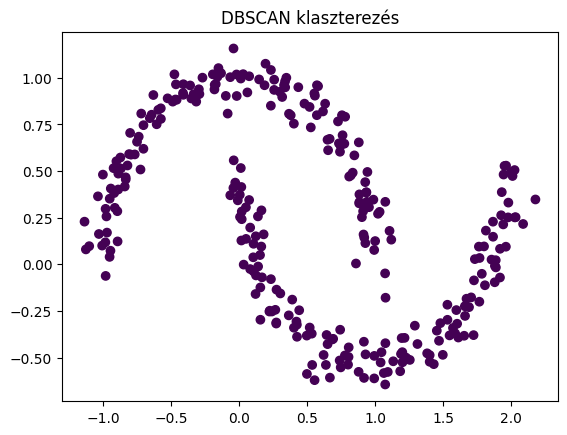

In [ ]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.5, min_samples=5) # min_samples: egy pont akkor magpont, ha legalább ennyi pont van a környezetében (eps sugarú környezet)
labels = model.fit_predict(X) # == dbscan.fit(X); labels = model.labels_

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN klaszterezés")

print("Összes adat:", X.shape[0]) # (300, 2)
print("Magpontok:", model.components_.shape[0]) # (257, 2)
# lilák az outlierek (nem tartoznak egyik klaszterhez sem, -1 a labeljük), a többi szín a klasztereket jelöli

## Metrikák

### Silhouette Score 
  - egy klaszterezési teljesítménymutató, amely figyelembe veszi:
      - a pont és a saját klaszterének többi pontja közötti átlagos távolságot (a), __kohézió__
      - valamint a pont és a legközelebbi másik klaszter pontjai közötti átlagos távolságot (b), __szeparáció__
  - minden pontra kiszámítható a) és b), és így ebből $s_i=(b_i-a_i)/max(a_i,b_i)$
  - a klaszter score-ja, a pontok score-jainak átlaga
  - teljes adathalmazra: az s értékek átlaga mutatja a klaszterezés általános minőségét, __de jól szétválasztható (pl. gömbszerű) klasztereket jutalmazza__ (...ha nem ilyenek, érdemes megfontolni az ARI-t, lásd alább)
  - értelmezés:
    - s közel 1: jól elkülönülő klaszterek, ill. a pont jó helyen van
    - s közel 0: klaszterek átfedhetnek, ill. határon lévő pont
    - s közel -1: a pont rossz klaszterbe került


### Rand Index (RI), Adjusted Rand Index (ARI)
  - a címkék eltérhetnek (kapott vs. ground truth), de attól még jó lehet a klaszterezés, csak más "neve", azonosítója van a klasztereknek
- minden párra:
  - P: egy klaszterben van két pont, N: nem egy kalszterben vannak 
  - azonosak a címkék (kapott vs. ground truth)? => TP (_függetlenül_ a címke tényleges értékétől)
  - különböznek mindkét esetben => TN
  - ... FP, FN (kapott egyezik, kapott nem egyezik, de a ground truth más)
  - __accuracy__-t számolhatunk: RI=(TP+TN)/összes
- az ARI ezen felül összehasonlítja ezt a _random klaszterezéssel_, ebből számít \[-1, 1\], normalizált értéket
- ARI értéke: −1 és 1 között (1: tökéletes klaszterezés, 0: véletlen szint, <0: rosszabb, mint a véletlen)
- robusztusabb nemlineáris klaszterezési feladatok esetén
- következtetés: ne csak egyetlen metrikára hagyatkozzunk — a vizuális értékelés is fontos!

In [11]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

sil = silhouette_score(X, labels)
ari = adjusted_rand_score(y_true, labels)

print("Silhouette score:", sil)
print("ARI score:", ari)

Silhouette score: 0.6819938690643478
ARI score: 1.0


### Feladat

- Generálj adathalmazt: make_moons(n_samples=300, noise=0.07)
- Vizualizáld az adatokat 2D-ben
- Alkalmazz klaszterezési algoritmusokat:
    - KMeans
    - GMM
    - DBSCAN
- Vizualizáld az eredményeket (színezés klasztercímkék alapján)
- Értékeld az eredményeket
- Melyik algoritmus adja a legjobb eredményt? Miért?

Text(0.5, 1.0, 'KMeans')

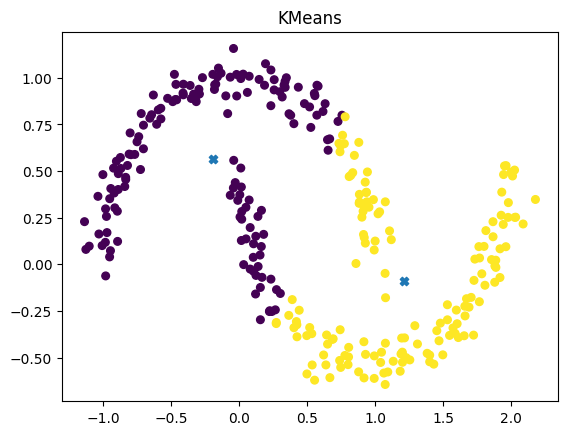

In [26]:
from sklearn.datasets import make_moons

X, y_true = make_moons(n_samples=300, noise=0.07, random_state=0)


#kmeans
model = KMeans(n_clusters=2, random_state=42)
model.fit(X)
pred = model.predict(X)
plt.scatter(X[:,0], X[:,1], c=pred, s=30)

plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker="X")
plt.title("KMeans")


Text(0.5, 1.0, 'GMM')

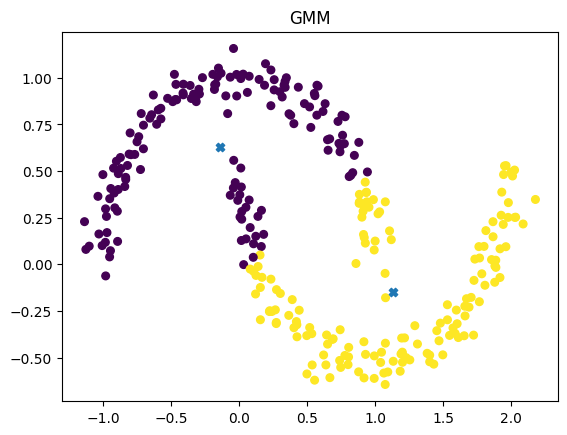

In [24]:
#gmm
from sklearn.mixture import GaussianMixture

gModel = GaussianMixture(n_components=2, random_state=42)
gModel.fit(X)
gPred = gModel.predict(X)
plt.scatter(X[:,0], X[:,1], c=gPred, s=30)

plt.scatter(gModel.means_[:,0], gModel.means_[:,1] ,marker="X")
plt.title("GMM")

Text(0.5, 1.0, 'DBSCAN')

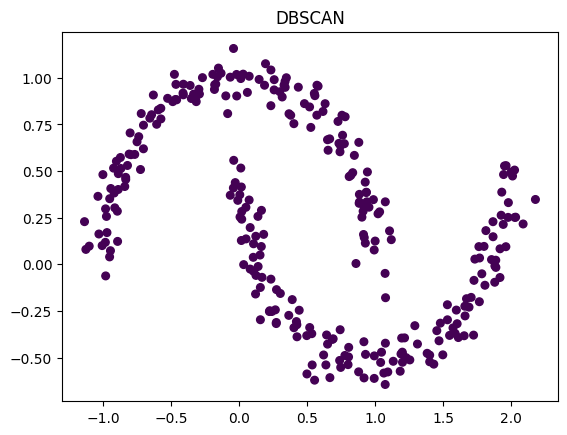

In [23]:
#dbscan
model = DBSCAN(eps=0.5, min_samples=5)
model.fit(X)
dbPred = model.labels_
plt.scatter(X[:,0], X[:,1], c=dbPred, s=30)
plt.title("DBSCAN")